# SVM — Anti-Money Laundering (AML)

### Contextualización Teórica
Las Máquinas de Vectores de Soporte (*Support Vector Machines* - SVM) tienen una lógica determinista fundamentada en la geometría: persiguen delinear y encontrar un hiperplano interclasificador (*Margen Máximo*) óptimo que destierre a los estafadores de los individuos legítimos dentro del espacio dimensional. En escenarios transaccionales complejos o donde la interconexión no es linealmente escalable, SVM manipula los datos utilizando transformaciones de hiperespacio. Sin embargo, su complejidad matemática nativa de matriz ($\mathcal{O}(n^2)$) lo hace extremadamente pesado. Mediante la aproximación de sus pesos combinados a través de **SGD (*Stochastic Gradient Descent*)**, conseguimos entrenar el esquema de SVM frente a volúmenes masivos de datos bancarios veloz e iterativamente.

## Sección 1 · Imports y Configuración


In [1]:
!pip install deap optuna -q

import warnings, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import loguniform, randint
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc, f1_score)
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.base import BaseSampler
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)
from deap import base, creator, tools, algorithms
warnings.filterwarnings('ignore')
sns.set_theme(style='ticks', context='paper', font_scale=1.2, palette='Set1')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 23.6 MB/s eta 0:00:00


In [2]:
RANDOM_STATE    = 42
N_SPLITS        = 3
N_ITER_RANDOM   = 20
N_TRIALS_OPTUNA = 30
POP_SIZE        = 10
N_GEN           = 5
BASE_PATH       = '/content/drive/MyDrive/Datasets/Final Project/Processed/'
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## Sección 2 · Clases Auxiliares


In [3]:
class IdentitySampler(BaseSampler):
    _sampling_type = 'bypass'
    _parameter_constraints = {}
    def _fit_resample(self, X, y): return X, y
    def __repr__(self): return 'IdentitySampler()'


class BalancedSGD(BaseEstimator, ClassifierMixin):
    def __init__(self, use_balanced_weight=False, alpha=1e-4, max_iter=1000, random_state=RANDOM_STATE):
        self.use_balanced_weight = use_balanced_weight
        self.alpha = alpha; self.max_iter = max_iter; self.random_state = random_state
    def fit(self, X, y, **kw):
        cw = 'balanced' if self.use_balanced_weight else None
        m  = SGDClassifier(loss='hinge', alpha=self.alpha, max_iter=self.max_iter,
                           class_weight=cw, random_state=self.random_state, n_jobs=1)
        self.cal_ = CalibratedClassifierCV(m, cv=3, method='sigmoid')
        self.cal_.fit(X, y); return self
    def predict(self, X): return self.cal_.predict(X)
    def predict_proba(self, X): return self.cal_.predict_proba(X)


class BalancedLinearSVC(BaseEstimator, ClassifierMixin):
    def __init__(self, use_balanced_weight=False, C=1.0, max_iter=1000, random_state=RANDOM_STATE):
        self.use_balanced_weight = use_balanced_weight
        self.C = C; self.max_iter = max_iter; self.random_state = random_state
    def fit(self, X, y, **kw):
        cw  = 'balanced' if self.use_balanced_weight else None
        svc = LinearSVC(C=self.C, max_iter=self.max_iter, class_weight=cw, random_state=self.random_state)
        self.cal_ = CalibratedClassifierCV(svc, cv=3, method='sigmoid')
        self.cal_.fit(X, y); return self
    def predict(self, X): return self.cal_.predict(X)
    def predict_proba(self, X): return self.cal_.predict_proba(X)


class BalancedSVC(BaseEstimator, ClassifierMixin):
    """SVC con kernel RBF. Modelo base SVM. Nota: O(n²~n³) en entrenamiento."""
    def __init__(self, use_balanced_weight=False, C=1.0, gamma='scale', random_state=RANDOM_STATE):
        self.use_balanced_weight = use_balanced_weight
        self.C = C; self.gamma = gamma; self.random_state = random_state
    def fit(self, X, y, **kw):
        cw = 'balanced' if self.use_balanced_weight else None
        self.model_ = SVC(kernel='rbf', C=self.C, gamma=self.gamma,
                          class_weight=cw, probability=True, random_state=self.random_state)
        self.model_.fit(X, y); return self
    def predict(self, X): return self.model_.predict(X)
    def predict_proba(self, X): return self.model_.predict_proba(X)

## Sección 3 · Carga de Datos


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
X_train = pd.read_parquet(f'{BASE_PATH}X_train.parquet')
X_test  = pd.read_parquet(f'{BASE_PATH}X_test.parquet')
y_train = pd.read_parquet(f'{BASE_PATH}y_train.parquet')['Is Laundering']
y_test  = pd.read_parquet(f'{BASE_PATH}y_test.parquet')['Is Laundering']
print(f'X_train: {X_train.shape} | Prevalencia: {y_train.mean():.4%}')

X_train: (4062668, 45) | Prevalencia: 0.0832%


## Sección 4 · Configuraciones Compartidas


In [6]:
TSCV = TimeSeriesSplit(n_splits=N_SPLITS)

BALANCE_CONFIGS = [
    {'id': 0, 'name': 'Sin balanceo',           'use_bw': False},
    {'id': 1, 'name': 'SMOTE',                   'use_bw': False},
    {'id': 2, 'name': 'ADASYN',                  'use_bw': False},
    {'id': 3, 'name': "class_weight='balanced'", 'use_bw': True },
]

def get_fresh_sampler(bal_id):
    if bal_id == 1: return SMOTE(random_state=RANDOM_STATE)
    if bal_id == 2: return ADASYN(random_state=RANDOM_STATE)
    return IdentitySampler()

PARAM_GRID_SGD  = {'clf__alpha': [1e-5, 1e-4, 1e-3], 'clf__max_iter': [500, 1000]}
PARAM_DIST_SGD  = {'clf__alpha': loguniform(1e-6, 1e-1), 'clf__max_iter': randint(200, 2001)}
PARAM_GRID_LSVC = {'clf__C': [0.01, 0.1, 1.0, 10.0], 'clf__max_iter': [500, 1000]}
PARAM_DIST_LSVC = {'clf__C': loguniform(1e-3, 1e2), 'clf__max_iter': randint(200, 2001)}
PARAM_GRID_SVC  = {'clf__C': [0.1, 1.0, 10.0], 'clf__gamma': ['scale', 'auto']}
PARAM_DIST_SVC  = {'clf__C': loguniform(1e-2, 1e3), 'clf__gamma': ['scale', 'auto']}
GAMMA_OPTIONS   = ['scale', 'auto']
RESULTS = {}

In [7]:
# ── Helpers convergencia y DEAP ───────────────────────────────────────────────
def converged_optuna(study, patience=10):
    vals = [t.value for t in study.trials if t.value is not None]
    if len(vals) < patience: return False
    best = [max(vals[:i+1]) for i in range(len(vals))]
    return len(set(best[-patience:])) == 1

def converged_deap(logbook, patience=2):
    maxes = logbook.select('max')
    if len(maxes) <= patience: return False
    return maxes[-1] == maxes[-(patience+1)]

def _init_deap_toolbox(evaluate_fn, mutate_fn, attr_fns, X_train, y_train):
    if hasattr(creator,'FitnessMax'): del creator.FitnessMax
    if hasattr(creator,'Individual'): del creator.Individual
    creator.create('FitnessMax', base.Fitness, weights=(1.0,))
    creator.create('Individual', list, fitness=creator.FitnessMax)
    cv = TimeSeriesSplit(n_splits=N_SPLITS)
    tb = base.Toolbox()
    for name, fn in attr_fns: tb.register(name, fn)
    tb.register('individual', tools.initCycle, creator.Individual,
                tuple(getattr(tb, n) for n,_ in attr_fns), n=1)
    tb.register('population', tools.initRepeat, list, tb.individual)
    tb.register('evaluate', evaluate_fn, X=X_train, y=y_train, cv=cv)
    tb.register('mate', tools.cxTwoPoint)
    tb.register('mutate', mutate_fn, indpb=0.2)
    tb.register('select', tools.selTournament, tournsize=3)
    return tb

def _run_deap(toolbox, pop_size, n_gen):
    pop = toolbox.population(n=pop_size)
    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register('avg', np.mean); stats.register('max', np.max)
    t0 = time.time()
    pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2,
                                       ngen=n_gen, stats=stats, halloffame=hof, verbose=True)
    return hof[0], logbook, (time.time()-t0)/60

In [8]:
def build_final_model(spec, X_train, y_train):
    bal_cfg = BALANCE_CONFIGS[spec['bal_id']]
    sampler = get_fresh_sampler(spec['bal_id'])
    use_bw  = bal_cfg['use_bw']
    if spec['svm_config'] == 'sgd':
        clf = BalancedSGD(use_balanced_weight=use_bw, alpha=spec['alpha'], max_iter=spec['max_iter'])
    elif spec['svm_config'] == 'lsvc':
        clf = BalancedLinearSVC(use_balanced_weight=use_bw, C=spec['C'], max_iter=spec['max_iter'])
    else:
        clf = BalancedSVC(use_balanced_weight=use_bw, C=spec['C'], gamma=spec['gamma'])
    pipe = Pipeline([('scaler',StandardScaler()),('sampler',sampler),('clf',clf)])
    pipe.fit(X_train, y_train); return pipe

def predict_final(model, X_test):
    return model.predict(X_test), model.predict_proba(X_test)[:,1]

## Secciones 5–8 · SGD (Grid Search / Random Search / Bayesiano / DEAP)


In [9]:
# ── Helper genérico para Grid y Random Search ─────────────────────────────────
def _run_search(clf_cls, param_grid, param_dist, config_key, label, svm_config,
               extra_spec_fn, X_train, y_train, n_iter=None):
    is_grid = n_iter is None
    method  = 'Grid Search' if is_grid else 'Random Search'
    n_combos = 1
    if is_grid:
        for v in param_grid.values(): n_combos *= len(v)
    else:
        n_combos = n_iter
    print(f"{'═'*62}\n {method} — {label}\n{'═'*62}")
    best_f1, best_spec, best_bal_name = -1, None, None
    t0 = time.time()
    for bal_cfg in BALANCE_CONFIGS:
        clf  = clf_cls(use_balanced_weight=bal_cfg['use_bw'])
        pipe = Pipeline([('scaler',StandardScaler()),('sampler',get_fresh_sampler(bal_cfg['id'])),('clf',clf)])
        if is_grid:
            search = GridSearchCV(pipe, param_grid, cv=TSCV, scoring='f1', n_jobs=-1, refit=False)
        else:
            search = RandomizedSearchCV(pipe, param_dist, n_iter=n_iter, cv=TSCV,
                                        scoring='f1', n_jobs=-1, refit=False, random_state=RANDOM_STATE)
        search.fit(X_train, y_train)
        score = search.best_score_
        print(f"  [{bal_cfg['name']:35s}]  F1 CV = {score:.4f}")
        if score > best_f1:
            best_f1, best_bal_name = score, bal_cfg['name']
            best_spec = extra_spec_fn(search.best_params_, bal_cfg['id'], svm_config)
    elapsed = (time.time()-t0)/60
    print(f"\n  ✓ Mejor F1 : {best_f1:.4f}  |  Balanceo : {best_bal_name}  |  Tiempo : {elapsed:.1f} min")
    key = f'{config_key}_{"grid" if is_grid else "random"}'
    RESULTS[key] = {'label':label,'method':method,'svm_config':svm_config,
                    'best_f1':round(best_f1,4),'time_min':round(elapsed,2),
                    'n_evals':n_combos*len(BALANCE_CONFIGS),'converged':'N/A',
                    'best_balance':best_bal_name,'spec':best_spec}
    return RESULTS[key]

# ── SGD spec builder ──────────────────────────────────────────────────────────
def sgd_spec(p, bal_id, svm_config):
    return {'svm_config':svm_config,'bal_id':bal_id,'alpha':p['clf__alpha'],'max_iter':p['clf__max_iter']}

result_sgd_grid   = _run_search(BalancedSGD, PARAM_GRID_SGD, PARAM_DIST_SGD,
                                'sgd','SGD','sgd', sgd_spec, X_train, y_train)
result_sgd_random = _run_search(BalancedSGD, PARAM_GRID_SGD, PARAM_DIST_SGD,
                                'sgd','SGD','sgd', sgd_spec, X_train, y_train, n_iter=N_ITER_RANDOM)

══════════════════════════════════════════════════════════════
 Grid Search — SGD
══════════════════════════════════════════════════════════════
  [Sin balanceo                       ]  F1 CV = 0.0072
  [SMOTE                              ]  F1 CV = 0.0280
  [ADASYN                             ]  F1 CV = 0.0219
  [class_weight='balanced'            ]  F1 CV = 0.0000

  ✓ Mejor F1 : 0.0280  |  Balanceo : SMOTE  |  Tiempo : 13.5 min
══════════════════════════════════════════════════════════════
 Random Search — SGD
══════════════════════════════════════════════════════════════
  [Sin balanceo                       ]  F1 CV = 0.0072
  [SMOTE                              ]  F1 CV = 0.0286
  [ADASYN                             ]  F1 CV = 0.0226
  [class_weight='balanced'            ]  F1 CV = 0.0006

  ✓ Mejor F1 : 0.0286  |  Balanceo : SMOTE  |  Tiempo : 42.3 min


In [10]:
# ── SGD Bayesiano ─────────────────────────────────────────────────────────────
def run_optuna_sgd(X_train, y_train, n_trials=N_TRIALS_OPTUNA):
    print(f"{'═'*62}\n Bayesiano (Optuna/TPE) — SGD\n{'═'*62}")
    def objective(trial):
        bal_id = trial.suggest_int('bal',0,3)
        alpha  = trial.suggest_float('alpha',1e-6,1e-1,log=True)
        mi     = trial.suggest_int('max_iter',200,2000)
        bc     = BALANCE_CONFIGS[bal_id]
        pipe = Pipeline([('scaler',StandardScaler()),('sampler',get_fresh_sampler(bal_id)),
                         ('clf',BalancedSGD(use_balanced_weight=bc['use_bw'],alpha=alpha,max_iter=mi))])
        return cross_val_score(pipe,X_train,y_train,cv=TSCV,scoring='f1',n_jobs=-1,error_score=0.0).mean()
    t0=time.time(); study=optuna.create_study(direction='maximize',sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective,n_trials=n_trials,show_progress_bar=True)
    elapsed=(time.time()-t0)/60; best=study.best_trial; bc=BALANCE_CONFIGS[best.params['bal']]
    conv=converged_optuna(study)
    print(f"\n  ✓ Mejor F1 : {best.value:.4f}  |  Balanceo : {bc['name']}  |  ¿Convergió? : {'Sí' if conv else 'No'}")
    RESULTS['sgd_optuna']={'label':'SGD','method':'Bayesiano','svm_config':'sgd',
                           'best_f1':round(best.value,4),'time_min':round(elapsed,2),'n_evals':n_trials,
                           'converged':'Sí' if conv else 'No','best_balance':bc['name'],'study':study,
                           'spec':{'svm_config':'sgd','bal_id':best.params['bal'],
                                   'alpha':best.params['alpha'],'max_iter':best.params['max_iter']}}
    return RESULTS['sgd_optuna']
result_sgd_optuna = run_optuna_sgd(X_train, y_train)

══════════════════════════════════════════════════════════════
 Bayesiano (Optuna/TPE) — SGD
══════════════════════════════════════════════════════════════


  0%|          | 0/30 [00:00<?, ?it/s]


  ✓ Mejor F1 : 0.0281  |  Balanceo : SMOTE  |  ¿Convergió? : No


In [11]:
# ── SGD DEAP ──────────────────────────────────────────────────────────────────
def mutate_sgd(ind, indpb):
    if random.random()<indpb: ind[0]=random.randint(0,3)
    if random.random()<indpb: ind[1]=10**random.uniform(-6,-1)
    if random.random()<indpb: ind[2]=random.randint(200,2000)
    return ind,
def evaluate_sgd(ind, X, y, cv):
    bc=BALANCE_CONFIGS[int(ind[0])]
    pipe=Pipeline([('scaler',StandardScaler()),('sampler',get_fresh_sampler(int(ind[0]))),
                   ('clf',BalancedSGD(use_balanced_weight=bc['use_bw'],alpha=ind[1],max_iter=int(ind[2])))])
    return (cross_val_score(pipe,X,y,cv=cv,scoring='f1',n_jobs=-1,error_score=0.0).mean(),)
def run_deap_sgd(X_train, y_train, pop_size=POP_SIZE, n_gen=N_GEN):
    print(f"{'═'*62}\n DEAP (Genético) — SGD\n{'═'*62}")
    attr_fns=[('a0',lambda:random.randint(0,3)),('a1',lambda:10**random.uniform(-6,-1)),
              ('a2',lambda:random.randint(200,2000))]
    tb=_init_deap_toolbox(evaluate_sgd,mutate_sgd,attr_fns,X_train,y_train)
    best,logbook,elapsed=_run_deap(tb,pop_size,n_gen)
    bal_id=int(best[0]); bal_name=BALANCE_CONFIGS[bal_id]['name']; conv=converged_deap(logbook)
    print(f"\n  ✓ Mejor F1 : {best.fitness.values[0]:.4f}  |  Balanceo : {bal_name}  |  ¿Convergió? : {'Sí' if conv else 'No'}")
    RESULTS['sgd_deap']={'label':'SGD','method':'DEAP (Genético)','svm_config':'sgd',
                         'best_f1':round(best.fitness.values[0],4),'time_min':round(elapsed,2),
                         'n_evals':pop_size*n_gen,'converged':'Sí' if conv else 'No',
                         'best_balance':bal_name,'logbook':logbook,
                         'spec':{'svm_config':'sgd','bal_id':bal_id,'alpha':best[1],'max_iter':int(best[2])}}
    return RESULTS['sgd_deap']
result_sgd_deap = run_deap_sgd(X_train, y_train)

══════════════════════════════════════════════════════════════
 DEAP (Genético) — SGD
══════════════════════════════════════════════════════════════
gen	nevals	avg      	max      
0  	10    	0.0110938	0.0261683
1  	6     	0.0244837	0.0261683
2  	4     	0.0253212	0.0261683
3  	8     	0.0258608	0.0261683
4  	7     	0.0234636	0.0261683
5  	9     	0.0242246	0.0261683

  ✓ Mejor F1 : 0.0262  |  Balanceo : SMOTE  |  ¿Convergió? : Sí


## Secciones 9–12 · LinearSVC (Grid Search / Random Search / Bayesiano / DEAP)


In [13]:
def lsvc_spec(p, bal_id, svm_config):
    return {'svm_config':svm_config,'bal_id':bal_id,'C':p['clf__C'],'max_iter':p['clf__max_iter']}
result_lsvc_grid   = _run_search(BalancedLinearSVC, PARAM_GRID_LSVC, PARAM_DIST_LSVC,
                                 'lsvc','LinearSVC','lsvc', lsvc_spec, X_train, y_train)
result_lsvc_random = _run_search(BalancedLinearSVC, PARAM_GRID_LSVC, PARAM_DIST_LSVC,
                                 'lsvc','LinearSVC','lsvc', lsvc_spec, X_train, y_train, n_iter=N_ITER_RANDOM)

══════════════════════════════════════════════════════════════
 Grid Search — LinearSVC
══════════════════════════════════════════════════════════════
  [Sin balanceo                       ]  F1 CV = 0.0000


TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

The exit codes of the workers are {SIGKILL(-9)}
Detailed tracebacks of the workers should have been printed to stderr in the executor process if faulthandler was not disabled.

In [14]:
def run_optuna_lsvc(X_train, y_train, n_trials=N_TRIALS_OPTUNA):
    print(f"{'═'*62}\n Bayesiano (Optuna/TPE) — LinearSVC\n{'═'*62}")
    def objective(trial):
        bal_id=trial.suggest_int('bal',0,3); C=trial.suggest_float('C',1e-3,1e2,log=True)
        mi=trial.suggest_int('max_iter',200,2000); bc=BALANCE_CONFIGS[bal_id]
        pipe=Pipeline([('scaler',StandardScaler()),('sampler',get_fresh_sampler(bal_id)),
                        ('clf',BalancedLinearSVC(use_balanced_weight=bc['use_bw'],C=C,max_iter=mi))])
        return cross_val_score(pipe,X_train,y_train,cv=TSCV,scoring='f1',n_jobs=-1,error_score=0.0).mean()
    t0=time.time(); study=optuna.create_study(direction='maximize',sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective,n_trials=n_trials,show_progress_bar=True)
    elapsed=(time.time()-t0)/60; best=study.best_trial; bc=BALANCE_CONFIGS[best.params['bal']]
    conv=converged_optuna(study)
    print(f"\n  ✓ Mejor F1 : {best.value:.4f}  |  Balanceo : {bc['name']}  |  ¿Convergió? : {'Sí' if conv else 'No'}")
    RESULTS['lsvc_optuna']={'label':'LinearSVC','method':'Bayesiano','svm_config':'lsvc',
                            'best_f1':round(best.value,4),'time_min':round(elapsed,2),'n_evals':n_trials,
                            'converged':'Sí' if conv else 'No','best_balance':bc['name'],'study':study,
                            'spec':{'svm_config':'lsvc','bal_id':best.params['bal'],
                                    'C':best.params['C'],'max_iter':best.params['max_iter']}}
    return RESULTS['lsvc_optuna']
result_lsvc_optuna = run_optuna_lsvc(X_train, y_train)

══════════════════════════════════════════════════════════════
 Bayesiano (Optuna/TPE) — LinearSVC
══════════════════════════════════════════════════════════════


  0%|          | 0/30 [00:00<?, ?it/s]


  ✓ Mejor F1 : 0.0298  |  Balanceo : SMOTE  |  ¿Convergió? : No


In [15]:
def mutate_lsvc(ind, indpb):
    if random.random()<indpb: ind[0]=random.randint(0,3)
    if random.random()<indpb: ind[1]=10**random.uniform(-3,2)
    if random.random()<indpb: ind[2]=random.randint(200,2000)
    return ind,
def evaluate_lsvc(ind, X, y, cv):
    bc=BALANCE_CONFIGS[int(ind[0])]
    pipe=Pipeline([('scaler',StandardScaler()),('sampler',get_fresh_sampler(int(ind[0]))),
                   ('clf',BalancedLinearSVC(use_balanced_weight=bc['use_bw'],C=ind[1],max_iter=int(ind[2])))])
    return (cross_val_score(pipe,X,y,cv=cv,scoring='f1',n_jobs=-1,error_score=0.0).mean(),)
def run_deap_lsvc(X_train, y_train, pop_size=POP_SIZE, n_gen=N_GEN):
    print(f"{'═'*62}\n DEAP (Genético) — LinearSVC\n{'═'*62}")
    attr_fns=[('a0',lambda:random.randint(0,3)),('a1',lambda:10**random.uniform(-3,2)),
              ('a2',lambda:random.randint(200,2000))]
    tb=_init_deap_toolbox(evaluate_lsvc,mutate_lsvc,attr_fns,X_train,y_train)
    best,logbook,elapsed=_run_deap(tb,pop_size,n_gen)
    bal_id=int(best[0]); bal_name=BALANCE_CONFIGS[bal_id]['name']; conv=converged_deap(logbook)
    print(f"\n  ✓ Mejor F1 : {best.fitness.values[0]:.4f}  |  Balanceo : {bal_name}  |  ¿Convergió? : {'Sí' if conv else 'No'}")
    RESULTS['lsvc_deap']={'label':'LinearSVC','method':'DEAP (Genético)','svm_config':'lsvc',
                          'best_f1':round(best.fitness.values[0],4),'time_min':round(elapsed,2),
                          'n_evals':pop_size*n_gen,'converged':'Sí' if conv else 'No',
                          'best_balance':bal_name,'logbook':logbook,
                          'spec':{'svm_config':'lsvc','bal_id':bal_id,'C':best[1],'max_iter':int(best[2])}}
    return RESULTS['lsvc_deap']
result_lsvc_deap = run_deap_lsvc(X_train, y_train)

══════════════════════════════════════════════════════════════
 DEAP (Genético) — LinearSVC
══════════════════════════════════════════════════════════════
gen	nevals	avg      	max      
0  	10    	0.0199525	0.0295658
1  	10    	0.027607 	0.0303126
2  	6     	0.029358 	0.0303126
3  	5     	0.030162 	0.0303126
4  	6     	0.030331 	0.0304971
5  	8     	0.0304602	0.0304971

  ✓ Mejor F1 : 0.0305  |  Balanceo : SMOTE  |  ¿Convergió? : No


## Secciones 13–16 · SVC RBF (Grid Search / Random Search / Bayesiano / DEAP)


In [16]:
def svc_spec(p, bal_id, svm_config):
    return {'svm_config':svm_config,'bal_id':bal_id,'C':p['clf__C'],'gamma':p['clf__gamma']}
result_svc_grid   = _run_search(BalancedSVC, PARAM_GRID_SVC, PARAM_DIST_SVC,
                                'svc','SVC (RBF)','svc', svc_spec, X_train, y_train)
result_svc_random = _run_search(BalancedSVC, PARAM_GRID_SVC, PARAM_DIST_SVC,
                                'svc','SVC (RBF)','svc', svc_spec, X_train, y_train, n_iter=N_ITER_RANDOM)

══════════════════════════════════════════════════════════════
 Grid Search — SVC (RBF)
══════════════════════════════════════════════════════════════


KeyboardInterrupt: 

In [17]:
def run_optuna_svc(X_train, y_train, n_trials=N_TRIALS_OPTUNA):
    print(f"{'═'*62}\n Bayesiano (Optuna/TPE) — SVC (RBF)\n{'═'*62}")
    def objective(trial):
        bal_id=trial.suggest_int('bal',0,3); C=trial.suggest_float('C',1e-2,1e3,log=True)
        gamma=trial.suggest_categorical('gamma',['scale','auto']); bc=BALANCE_CONFIGS[bal_id]
        pipe=Pipeline([('scaler',StandardScaler()),('sampler',get_fresh_sampler(bal_id)),
                        ('clf',BalancedSVC(use_balanced_weight=bc['use_bw'],C=C,gamma=gamma))])
        return cross_val_score(pipe,X_train,y_train,cv=TSCV,scoring='f1',n_jobs=-1,error_score=0.0).mean()
    t0=time.time(); study=optuna.create_study(direction='maximize',sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective,n_trials=n_trials,show_progress_bar=True)
    elapsed=(time.time()-t0)/60; best=study.best_trial; bc=BALANCE_CONFIGS[best.params['bal']]
    conv=converged_optuna(study)
    print(f"\n  ✓ Mejor F1 : {best.value:.4f}  |  Balanceo : {bc['name']}  |  ¿Convergió? : {'Sí' if conv else 'No'}")
    RESULTS['svc_optuna']={'label':'SVC (RBF)','method':'Bayesiano','svm_config':'svc',
                           'best_f1':round(best.value,4),'time_min':round(elapsed,2),'n_evals':n_trials,
                           'converged':'Sí' if conv else 'No','best_balance':bc['name'],'study':study,
                           'spec':{'svm_config':'svc','bal_id':best.params['bal'],
                                   'C':best.params['C'],'gamma':best.params['gamma']}}
    return RESULTS['svc_optuna']
result_svc_optuna = run_optuna_svc(X_train, y_train)

══════════════════════════════════════════════════════════════
 Bayesiano (Optuna/TPE) — SVC (RBF)
══════════════════════════════════════════════════════════════


  0%|          | 0/30 [00:00<?, ?it/s]

[W 2026-05-17 14:17:56,072] Trial 0 failed with parameters: {'bal': 1, 'C': 566.9849511478844, 'gamma': 'scale'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_34844/4243651068.py", line 8, in objective
    return cross_val_score(pipe,X_train,y_train,cv=TSCV,scoring='f1',n_jobs=-1,error_score=0.0).mean()
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 684, in cross_val_score
    cv_results = cross_validate(
                 ^^^^^^^^^^^^^^^
  File "/u

KeyboardInterrupt: 

In [ ]:
def mutate_svc(ind, indpb):
    if random.random()<indpb: ind[0]=random.randint(0,3)
    if random.random()<indpb: ind[1]=10**random.uniform(-2,3)
    if random.random()<indpb: ind[2]=random.randint(0,1)
    return ind,
def evaluate_svc(ind, X, y, cv):
    bc=BALANCE_CONFIGS[int(ind[0])]; gamma=GAMMA_OPTIONS[int(ind[2])%2]
    pipe=Pipeline([('scaler',StandardScaler()),('sampler',get_fresh_sampler(int(ind[0]))),
                   ('clf',BalancedSVC(use_balanced_weight=bc['use_bw'],C=ind[1],gamma=gamma))])
    return (cross_val_score(pipe,X,y,cv=cv,scoring='f1',n_jobs=-1,error_score=0.0).mean(),)
def run_deap_svc(X_train, y_train, pop_size=POP_SIZE, n_gen=N_GEN):
    print(f"{'═'*62}\n DEAP (Genético) — SVC (RBF)\n{'═'*62}")
    attr_fns=[('a0',lambda:random.randint(0,3)),('a1',lambda:10**random.uniform(-2,3)),
              ('a2',lambda:random.randint(0,1))]
    tb=_init_deap_toolbox(evaluate_svc,mutate_svc,attr_fns,X_train,y_train)
    best,logbook,elapsed=_run_deap(tb,pop_size,n_gen)
    bal_id=int(best[0]); gamma=GAMMA_OPTIONS[int(best[2])%2]
    bal_name=BALANCE_CONFIGS[bal_id]['name']; conv=converged_deap(logbook)
    print(f"\n  ✓ Mejor F1 : {best.fitness.values[0]:.4f}  |  Balanceo : {bal_name}  |  ¿Convergió? : {'Sí' if conv else 'No'}")
    RESULTS['svc_deap']={'label':'SVC (RBF)','method':'DEAP (Genético)','svm_config':'svc',
                         'best_f1':round(best.fitness.values[0],4),'time_min':round(elapsed,2),
                         'n_evals':pop_size*n_gen,'converged':'Sí' if conv else 'No',
                         'best_balance':bal_name,'logbook':logbook,
                         'spec':{'svm_config':'svc','bal_id':bal_id,'C':best[1],'gamma':gamma}}
    return RESULTS['svc_deap']
result_svc_deap = run_deap_svc(X_train, y_train)

## Sección 17 · Tabla Comparativa y Análisis de Convergencia
### 17.1 Tabla de Resultados


In [18]:
ORDER = ['sgd_grid','sgd_random','sgd_optuna','sgd_deap',
         'lsvc_grid','lsvc_random','lsvc_optuna','lsvc_deap']
rows = []
for k in ORDER:
    if k in RESULTS:
        r = RESULTS[k]
        rows.append({'Configuración':r['label'],'Método de Búsqueda':r['method'],
                     'Mejor F1-Score (CV)':r['best_f1'],'Tiempo Total (min)':r['time_min'],
                     'Iteraciones/Evaluaciones':r['n_evals'],'¿Convergió?':r['converged'],
                     'Mejor Balanceo':r['best_balance']})
comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

Configuración Método de Búsqueda  Mejor F1-Score (CV)  Tiempo Total (min)  Iteraciones/Evaluaciones ¿Convergió? Mejor Balanceo
          SGD        Grid Search               0.0280               13.52                        24         N/A          SMOTE
          SGD      Random Search               0.0286               42.25                        80         N/A          SMOTE
          SGD          Bayesiano               0.0281               31.50                        30          No          SMOTE
          SGD    DEAP (Genético)               0.0262               40.47                        50          Sí          SMOTE
    LinearSVC          Bayesiano               0.0298              191.78                        30          No          SMOTE
    LinearSVC    DEAP (Genético)               0.0305              294.82                        50          No          SMOTE


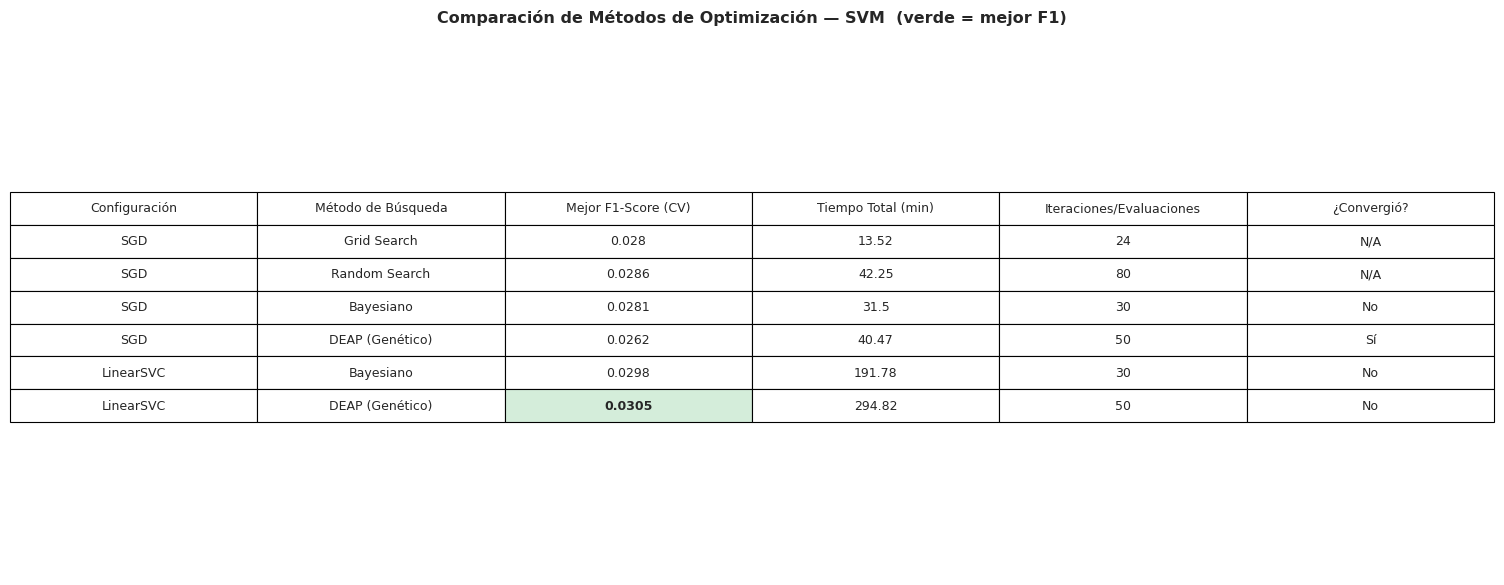

In [19]:
display_cols = ['Configuración','Método de Búsqueda','Mejor F1-Score (CV)',
                'Tiempo Total (min)','Iteraciones/Evaluaciones','¿Convergió?']
fig, ax = plt.subplots(figsize=(15, 6))
ax.axis('off')
tbl = ax.table(cellText=comparison_df[display_cols].values,colLabels=display_cols,cellLoc='center',loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.1, 1.7)
best_row = comparison_df['Mejor F1-Score (CV)'].idxmax()
f1_col   = display_cols.index('Mejor F1-Score (CV)')
tbl[best_row+1, f1_col].set_facecolor('#d4edda'); tbl[best_row+1, f1_col].set_text_props(fontweight='bold')
plt.title('Comparación de Métodos de Optimización — SVM  (verde = mejor F1)', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}tabla_comparacion_svm.png', dpi=150, bbox_inches='tight')
plt.show()

### 17.2 Convergencia Bayesiana (Optuna)


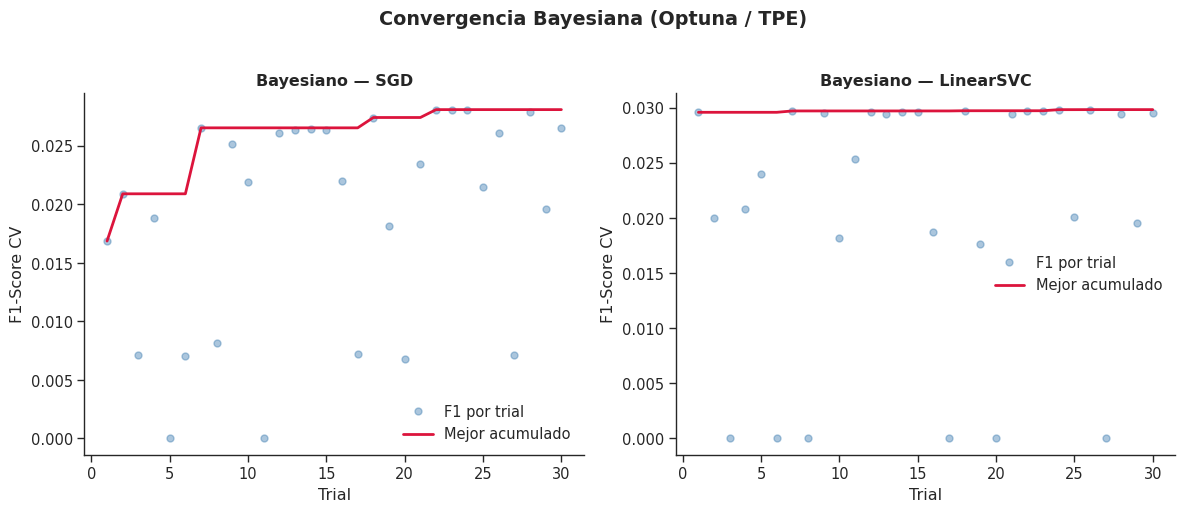

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, key, title in [(axes[0],'sgd_optuna','Bayesiano — SGD'),
                       (axes[1],'lsvc_optuna','Bayesiano — LinearSVC')]:
    if key in RESULTS:
        study=RESULTS[key]['study']
        tf=[t.value for t in study.trials if t.value is not None]
        bf=[max(tf[:i+1]) for i in range(len(tf))]
        ax.plot(range(1,len(tf)+1),tf,'o',color='steelblue',alpha=0.45,ms=5,label='F1 por trial')
        ax.plot(range(1,len(bf)+1),bf,'-',color='crimson',lw=2,label='Mejor acumulado')
        ax.set_xlabel('Trial'); ax.set_ylabel('F1-Score CV')
        ax.set_title(title,fontweight='bold'); ax.legend(frameon=False); sns.despine(ax=ax)
plt.suptitle('Convergencia Bayesiana (Optuna / TPE)',fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}convergencia_optuna_svm.png',dpi=150,bbox_inches='tight')
plt.show()

### 17.3 Convergencia Genética (DEAP)


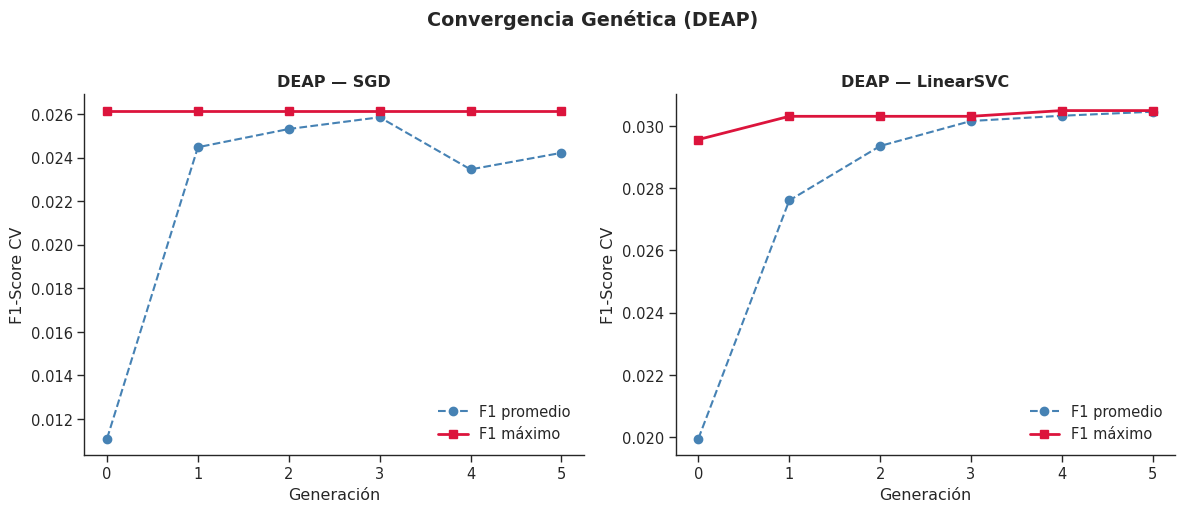

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, key, title in [(axes[0],'sgd_deap','DEAP — SGD'),
                       (axes[1],'lsvc_deap','DEAP — LinearSVC')]:
    if key in RESULTS:
        lb=RESULTS[key]['logbook']
        ax.plot(lb.select('gen'),lb.select('avg'),'o--',color='steelblue',lw=1.5,ms=6,label='F1 promedio')
        ax.plot(lb.select('gen'),lb.select('max'),'s-',color='crimson',lw=2,ms=6,label='F1 máximo')
        ax.set_xlabel('Generación'); ax.set_ylabel('F1-Score CV')
        ax.set_title(title,fontweight='bold'); ax.legend(frameon=False); sns.despine(ax=ax)
plt.suptitle('Convergencia Genética (DEAP)',fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}convergencia_deap_svm.png',dpi=150,bbox_inches='tight')
plt.show()

### 17.4 Eficiencia: F1 vs Tiempo


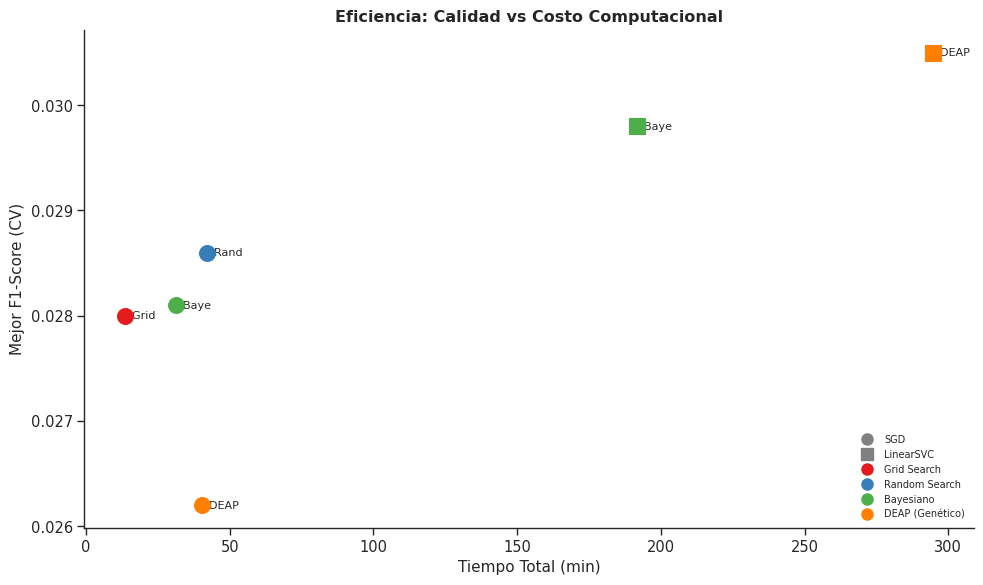

In [22]:
from matplotlib.lines import Line2D
colors_method  = {'Grid Search':'#E41A1C','Random Search':'#377EB8','Bayesiano':'#4DAF4A','DEAP (Genético)':'#FF7F00'}
markers_config = {'SGD':'o','LinearSVC':'s'}
fig, ax = plt.subplots(figsize=(10, 6))
for k in ORDER:
    if k in RESULTS:
        r=RESULTS[k]
        ax.scatter(r['time_min'],r['best_f1'],color=colors_method[r['method']],
                   marker=markers_config[r['label']],s=130,zorder=5)
        ax.annotate(f"  {r['method'][:4]}",(r['time_min'],r['best_f1']),fontsize=8,va='center')
legend_elems=[Line2D([0],[0],marker=mk,color='gray',linestyle='None',ms=8,label=lb)
              for lb,mk in markers_config.items()] + \
             [Line2D([0],[0],marker='o',color=c,linestyle='None',ms=8,label=m)
              for m,c in colors_method.items()]
ax.legend(handles=legend_elems,frameon=False,fontsize=7,loc='lower right')
ax.set_xlabel('Tiempo Total (min)',fontsize=11); ax.set_ylabel('Mejor F1-Score (CV)',fontsize=11)
ax.set_title('Eficiencia: Calidad vs Costo Computacional',fontweight='bold')
sns.despine(ax=ax); plt.tight_layout()
plt.savefig(f'{BASE_PATH}eficiencia_svm.png',dpi=150,bbox_inches='tight'); plt.show()

## Sección 18 · Evaluación Final y Exportación del Mejor Modelo


In [23]:
best_key=max(RESULTS,key=lambda k:RESULTS[k]['best_f1']); best_res=RESULTS[best_key]
print(f"{'═'*62}\n MEJOR CONFIGURACIÓN GLOBAL\n{'═'*62}")
print(f" Modelo: {best_res['label']} | Método: {best_res['method']}")
print(f" F1: {best_res['best_f1']} | Balanceo: {best_res['best_balance']}\n{'═'*62}")

══════════════════════════════════════════════════════════════
 MEJOR CONFIGURACIÓN GLOBAL
══════════════════════════════════════════════════════════════
 Modelo: LinearSVC | Método: DEAP (Genético)
 F1: 0.0305 | Balanceo: SMOTE
══════════════════════════════════════════════════════════════


In [24]:
print('Entrenando modelo final en todo X_train...')
final_model=build_final_model(best_res['spec'],X_train,y_train)
print('Modelo final entrenado ✓')
y_pred_final,y_proba_final=predict_final(final_model,X_test)

Entrenando modelo final en todo X_train...
Modelo final entrenado ✓


══════════════════════════════════════════════════════════════
 EVALUACIÓN FINAL — LinearSVC — DEAP (Genético)
══════════════════════════════════════════════════════════════
 Accuracy:0.9715 F1:0.0990 ROC-AUC:0.9771 PR-AUC:0.1829
              precision    recall  f1-score   support

    Legítima       1.00      0.97      0.99   1013870
      Lavado       0.05      0.89      0.10      1798

    accuracy                           0.97   1015668
   macro avg       0.53      0.93      0.54   1015668
weighted avg       1.00      0.97      0.98   1015668



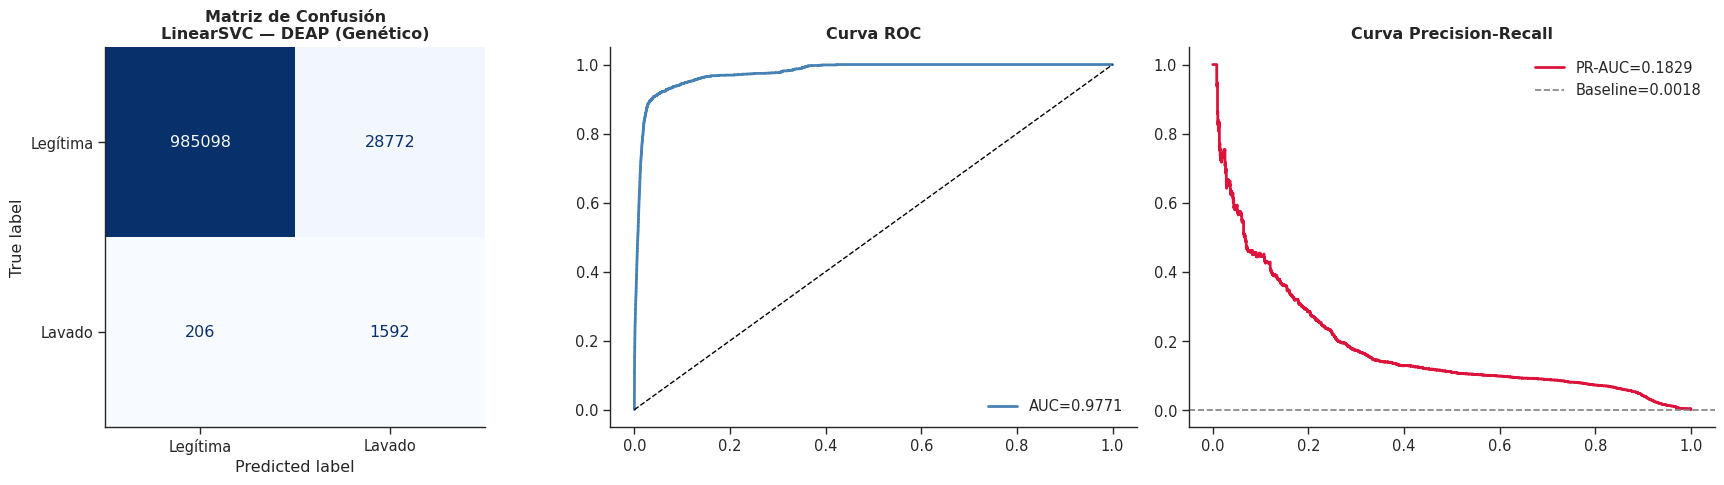

In [25]:
def evaluate_final_model(y_true,y_pred,y_proba,title):
    report=classification_report(y_true,y_pred,target_names=['Legítima','Lavado'],output_dict=True)
    prec_c,rec_c,_=precision_recall_curve(y_true,y_proba)
    fpr,tpr,_=roc_curve(y_true,y_proba)
    pr_auc=auc(rec_c,prec_c); roc_auc=auc(fpr,tpr)
    print(f"{'═'*62}\n EVALUACIÓN FINAL — {title}\n{'═'*62}")
    print(f" Accuracy:{report['accuracy']:.4f} F1:{report['Lavado']['f1-score']:.4f} ROC-AUC:{roc_auc:.4f} PR-AUC:{pr_auc:.4f}")
    print(classification_report(y_true,y_pred,target_names=['Legítima','Lavado']))
    fig,axes=plt.subplots(1,3,figsize=(18,5))
    ConfusionMatrixDisplay(confusion_matrix(y_true,y_pred),display_labels=['Legítima','Lavado']).plot(ax=axes[0],cmap='Blues',colorbar=False)
    axes[0].set_title(f'Matriz de Confusión\n{title}',fontweight='bold')
    axes[1].plot(fpr,tpr,lw=2,color='steelblue',label=f'AUC={roc_auc:.4f}'); axes[1].plot([0,1],[0,1],'k--',lw=1)
    axes[1].set_title('Curva ROC',fontweight='bold'); axes[1].legend(frameon=False)
    axes[2].plot(rec_c,prec_c,lw=2,color='crimson',label=f'PR-AUC={pr_auc:.4f}')
    axes[2].axhline(y_true.mean(),color='gray',linestyle='--',lw=1.2,label=f'Baseline={y_true.mean():.4f}')
    axes[2].set_title('Curva Precision-Recall',fontweight='bold'); axes[2].legend(frameon=False)
    sns.despine(); plt.tight_layout()
    plt.savefig(f'{BASE_PATH}evaluacion_final_svm.png',dpi=150,bbox_inches='tight'); plt.show()
eval_metrics=evaluate_final_model(y_test,y_pred_final,y_proba_final,f"{best_res['label']} — {best_res['method']}")

In [26]:
pd.DataFrame({'y_proba_svm':y_proba_final}).to_parquet(f'{BASE_PATH}y_proba_svm.parquet',index=False)
joblib.dump(final_model,f'{BASE_PATH}model_svm.joblib')
print(f"{'═'*62}\n Archivos exportados: y_proba_svm.parquet | model_svm.joblib\n{'═'*62}")

══════════════════════════════════════════════════════════════
 Archivos exportados: y_proba_svm.parquet | model_svm.joblib
══════════════════════════════════════════════════════════════


### Interpretación de Resultados Finales y Negocio AML

En un régimen abrumadoramente desbalanceado como el **Punto Crítico del Lavado de Dinero (AML)**, una métrica mal aplicada arriesga operaciones vitales. Usando un marco SVM + Estocástico interpretamos su viabilidad bancaria rigiéndonos por los siguientes cánones:

1. **Precision-Recall (PR-AUC) vs. Espejismos ROC-AUC:** La robustez operativa de un SVM no puede validarse meramente por ROC-AUC. ROC diluye y amortiza en el volumen total gigantesco de "No Lavados" las alarmas saltadas del modelo. Solamente el análisis de la curva **PR-AUC** desentraña la eficacia de los vectores de soporte para reunir y marginar transacciones ilegales puras mitigando el ruido (Falsos Fraudes).
2. **Recall vs Precisión al Límite Marginal:** Un hiperplano relajado lanzará numerosas Falsas Alarmas (Precision desplomado) sumergiendo a equipos investigadores financieros en ineficiencia de millones de dólares. Por el recíproco, un plano excesivamente tolerante (Bajo Recall) permite fuga de capital criminal en transacciones que pasan por normales. Maximizar el F1-Score sobre las funciones iterativas compensatorias equilibra precisamente este sesgo operacional.